Step 1: Discovering options from the environment's structure...
SR Learning: Episode 1000/5000
SR Learning: Episode 2000/5000
SR Learning: Episode 3000/5000
SR Learning: Episode 4000/5000
SR Learning: Episode 5000/5000
Options discovered! ✅

Step 2: Running multiple experiments to compare success rates...
--- Running Experiment 1/20 ---
--- Running Experiment 2/20 ---
--- Running Experiment 3/20 ---
--- Running Experiment 4/20 ---
--- Running Experiment 5/20 ---
--- Running Experiment 6/20 ---
--- Running Experiment 7/20 ---
--- Running Experiment 8/20 ---
--- Running Experiment 9/20 ---
--- Running Experiment 10/20 ---
--- Running Experiment 11/20 ---
--- Running Experiment 12/20 ---
--- Running Experiment 13/20 ---
--- Running Experiment 14/20 ---
--- Running Experiment 15/20 ---
--- Running Experiment 16/20 ---
--- Running Experiment 17/20 ---
--- Running Experiment 18/20 ---
--- Running Experiment 19/20 ---
--- Running Experiment 20/20 ---
Experiments complete! ✅

Step 3: Plotting 

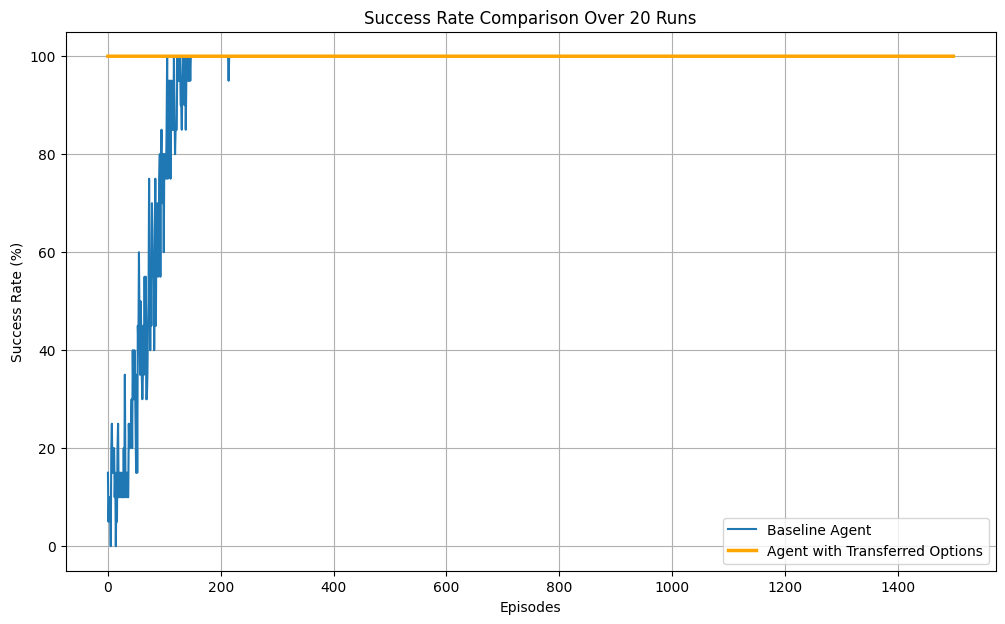

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. The Environment Definition (Unchanged) ---
class FourRooms:
    def __init__(self):
        layout = """
        XXXXXXXXXXX
        X....X....X
        X....X....X
        X....X....X
        X....D....X
        XXXXX.XXXXX
        X....D....X
        X....X....X
        X....X....X
        X....X....X
        XXXXXXXXXXX
        """
        self.layout = np.array([list(line.strip()) for line in layout.strip().split('\n')])
        self.grid = np.zeros_like(self.layout, dtype=int)
        self.grid[self.layout == 'X'] = 1
        self.valid_states = np.argwhere(self.grid != 1)
        self.num_states = len(self.valid_states)
        self.coord_to_state_idx = {tuple(coord): i for i, coord in enumerate(self.valid_states)}
        self.action_space = [0, 1, 2, 3] # 0:Up, 1:Down, 2:Left, 3:Right
        self.action_map = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def get_next_state(self, current_coord, action):
        move = self.action_map[action]
        next_coord = np.array(current_coord) + move
        if self.grid[next_coord[0], next_coord[1]] == 1:
            return tuple(current_coord)
        return tuple(next_coord)

# --- 2. Option Discovery (Unchanged) ---
def learn_successor_representation(env, alpha=0.1, gamma=0.98, n_episodes=5000):
    M = np.identity(env.num_states)
    for episode in range(n_episodes):
        start_idx = np.random.randint(env.num_states)
        current_coord = tuple(env.valid_states[start_idx])
        for _ in range(200):
            current_state_idx = env.coord_to_state_idx[current_coord]
            action = np.random.choice(env.action_space)
            next_coord = env.get_next_state(current_coord, action)
            next_state_idx = env.coord_to_state_idx[next_coord]
            one_hot_s = np.zeros(env.num_states)
            one_hot_s[current_state_idx] = 1
            td_error = one_hot_s + gamma * M[next_state_idx] - M[current_state_idx]
            M[current_state_idx] += alpha * td_error
            current_coord = next_coord
        if (episode + 1) % 1000 == 0: print(f"SR Learning: Episode {episode+1}/{n_episodes}")
    return M

# --- 3. Helper Functions (Unchanged) ---
def get_room(coord):
    r, c = coord
    if 1 <= r <= 4 and 1 <= c <= 4: return 1
    if 1 <= r <= 4 and 6 <= c <= 9: return 2
    if 6 <= r <= 9 and 1 <= c <= 4: return 3
    if 6 <= r <= 9 and 6 <= c <= 9: return 4
    return 0

# --- 4. The Unified RL Agent Class (Updated `train` method) ---
class RLAgent:
    def __init__(self, env, goal_idx, use_options=False, options=None, hyperparameters={}):
        self.env = env
        self.goal_idx = goal_idx
        self.use_options = use_options
        self.options = options if use_options else []
        self.alpha = hyperparameters.get('alpha', 0.1)
        self.gamma = hyperparameters.get('gamma', 0.99)
        self.epsilon = hyperparameters.get('epsilon', 1.0)
        self.epsilon_decay = hyperparameters.get('epsilon_decay', 0.998)
        self.min_epsilon = hyperparameters.get('min_epsilon', 0.01)
        self.option_bonus = hyperparameters.get('option_bonus', 20)
        self.num_primitive_actions = len(env.action_space)
        self.num_options = len(self.options)
        self.total_actions = self.num_primitive_actions + self.num_options
        self.q_table = np.zeros((env.num_states, self.total_actions))

    def _execute_option(self, current_coord, eigenvector):
        # This private method's logic is unchanged
        total_reward, num_steps = 0, 0
        for _ in range(30):
            num_steps += 1
            current_state_idx = self.env.coord_to_state_idx[tuple(current_coord)]
            best_next_coord, max_eigen_val = current_coord, eigenvector[current_state_idx]
            for action in self.env.action_space:
                next_coord = self.env.get_next_state(current_coord, action)
                next_state_idx = self.env.coord_to_state_idx[next_coord]
                if eigenvector[next_state_idx] > max_eigen_val:
                    max_eigen_val, best_next_coord = eigenvector[next_state_idx], next_coord
            if np.array_equal(best_next_coord, current_coord): break
            current_coord = best_next_coord
            reward = -1
            if self.env.coord_to_state_idx[tuple(current_coord)] == self.goal_idx:
                reward = 100
                total_reward += reward
                break
            total_reward += reward
        return tuple(current_coord), total_reward, num_steps

    def train(self, start_idx, n_episodes=1500):
        """
        UPDATED: This method now returns a boolean list indicating success for each episode.
        """
        successes_per_episode = []
        for episode in range(n_episodes):
            current_state_idx = start_idx
            goal_reached = False

            for _ in range(200):
                if random.uniform(0, 1) < self.epsilon:
                    action_choice = random.randrange(self.total_actions)
                else:
                    action_choice = np.argmax(self.q_table[current_state_idx])

                current_coord = self.env.valid_states[current_state_idx]

                if not self.use_options or action_choice < self.num_primitive_actions:
                    next_coord = self.env.get_next_state(current_coord, action_choice)
                    next_state_idx = self.env.coord_to_state_idx[next_coord]
                    reward = -1
                    done = (next_state_idx == self.goal_idx)
                    if done: reward = 100
                    old_value = self.q_table[current_state_idx, action_choice]
                    next_max = np.max(self.q_table[next_state_idx])
                    new_value = old_value + self.alpha * (reward + self.gamma * next_max - old_value)
                    self.q_table[current_state_idx, action_choice] = new_value
                    current_state_idx = next_state_idx
                else:
                    option_idx = action_choice - self.num_primitive_actions
                    eigenvector = self.options[option_idx]
                    final_coord, R_total, k_steps = self._execute_option(current_coord, eigenvector)
                    next_state_idx = self.env.coord_to_state_idx[final_coord]
                    done = (next_state_idx == self.goal_idx)
                    if not done and get_room(current_coord) != get_room(final_coord):
                        R_total += self.option_bonus
                    old_value = self.q_table[current_state_idx, action_choice]
                    next_max = np.max(self.q_table[next_state_idx])
                    new_value = old_value + self.alpha * (R_total + (self.gamma**k_steps) * next_max - old_value)
                    self.q_table[current_state_idx, action_choice] = new_value
                    current_state_idx = next_state_idx

                if done:
                    goal_reached = True
                    break

            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
            successes_per_episode.append(goal_reached)

        return successes_per_episode

# --- 5. Main Experiment Block ---
def run_multiple_experiments(env, options, num_runs=20, num_episodes=1500):
    """
    Runs the full experiment multiple times to gather success rate statistics.
    """
    all_baseline_successes = np.zeros((num_runs, num_episodes), dtype=bool)
    all_options_successes = np.zeros((num_runs, num_episodes), dtype=bool)

    target_start_coord = (9, 1)
    target_goal_coord = (1, 9)
    target_start_idx = env.coord_to_state_idx[target_start_coord]
    target_goal_idx = env.coord_to_state_idx[target_goal_coord]

    params = {
        'alpha': 0.1, 'gamma': 0.99, 'epsilon': 1.0,
        'epsilon_decay': 0.998, 'min_epsilon': 0.01, 'option_bonus': 20
    }

    for i in range(num_runs):
        print(f"--- Running Experiment {i+1}/{num_runs} ---")

        # Train baseline agent (fresh instance)
        baseline_agent = RLAgent(env, target_goal_idx, use_options=False, hyperparameters=params)
        baseline_successes = baseline_agent.train(target_start_idx, n_episodes=num_episodes)
        all_baseline_successes[i] = baseline_successes

        # Train options agent (fresh instance)
        options_agent = RLAgent(env, target_goal_idx, use_options=True, options=options, hyperparameters=params)
        options_successes = options_agent.train(target_start_idx, n_episodes=num_episodes)
        all_options_successes[i] = options_successes

    # Calculate success rates
    baseline_rate = np.mean(all_baseline_successes, axis=0) * 100
    options_rate = np.mean(all_options_successes, axis=0) * 100

    return baseline_rate, options_rate

if __name__ == "__main__":
    env = FourRooms()

    print("Step 1: Discovering options from the environment's structure...")
    M = learn_successor_representation(env, n_episodes=5000)
    eigenvalues, eigenvectors = np.linalg.eig(M)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenoptions = [eigenvectors[:, i].real for i in sorted_indices[1:5]]
    print("Options discovered! ✅\n")

    print("Step 2: Running multiple experiments to compare success rates...")
    baseline_success_rate, options_success_rate = run_multiple_experiments(env, eigenoptions)
    print("Experiments complete! ✅\n")

    print("Step 3: Plotting results...")
    plt.figure(figsize=(12, 7))
    plt.plot(baseline_success_rate, label='Baseline Agent')
    plt.plot(options_success_rate, label='Agent with Transferred Options', linewidth=2.5, color='orange')
    plt.xlabel('Episodes')
    plt.ylabel('Success Rate (%)')
    plt.title(f'Success Rate Comparison Over 20 Runs')
    plt.ylim(-5, 105) # y-axis from 0% to 100%
    plt.legend()
    plt.grid(True)
    plt.show()